In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)


In [4]:
df = pd.read_csv('/content/diabetic_data.csv')

In [5]:
df.head()
df.shape

(100227, 50)

In [6]:
df.isnull().sum()

,0
encounter_id,0
patient_nbr,0
race,1
gender,1
age,1
weight,1
admission_type_id,1
discharge_disposition_id,1
admission_source_id,1
time_in_hospital,1


In [7]:
missing = df.isnull().sum()

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percentage': round((missing / len(df)) * 100, 2)
})

missing_df.sort_values(
    by='Missing Count',
    ascending=False
)

,Missing Count,Missing Percentage
max_glu_serum,94899,94.68
A1Cresult,83483,83.29
payer_code,1,0.00
medical_specialty,1,0.00
age,1,0.00
weight,1,0.00
admission_type_id,1,0.00
discharge_disposition_id,1,0.00
admission_source_id,1,0.00
time_in_hospital,1,0.00


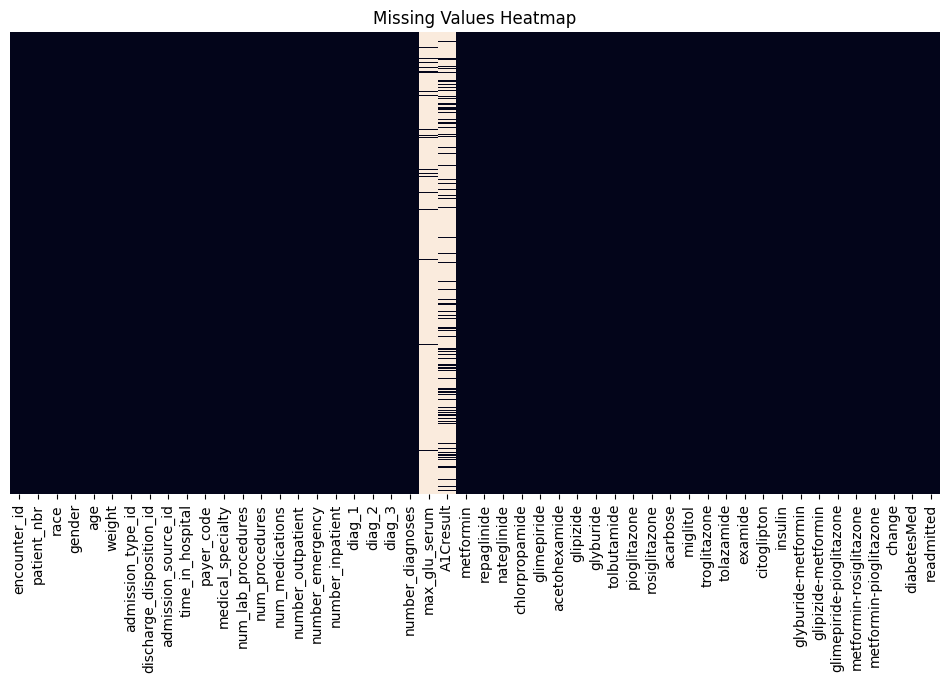

In [8]:
plt.figure(figsize=(12,6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title('Missing Values Heatmap')
plt.show()

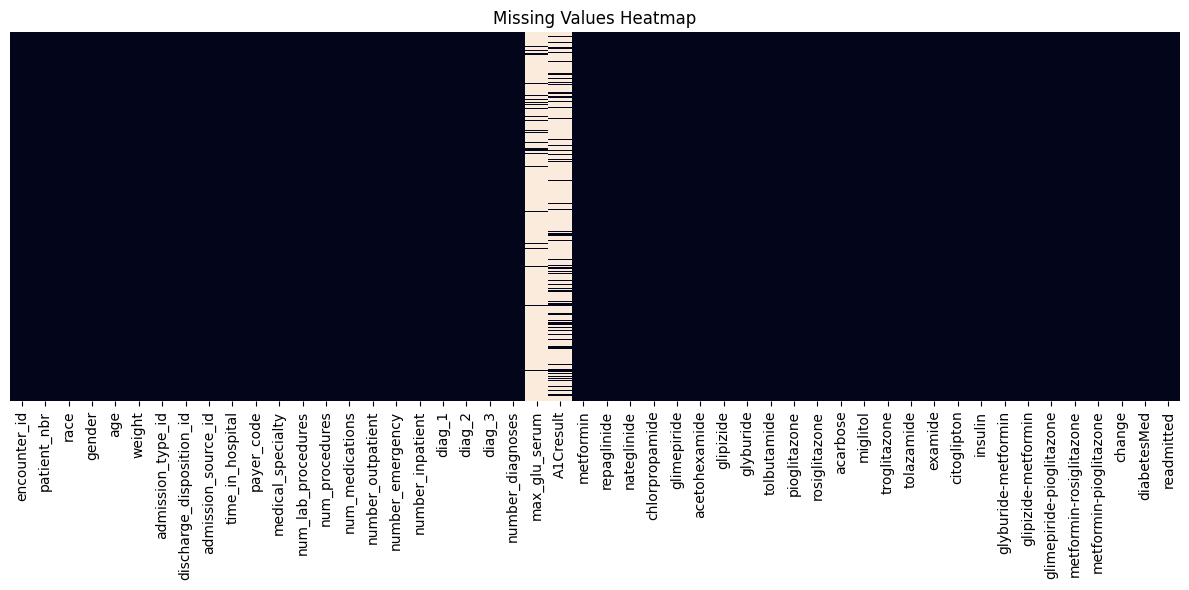

In [17]:
plt.figure(figsize=(12,6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title('Missing Values Heatmap')
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.savefig('Missing_Values_Heatmap.png') # Save the plot as a PNG file
plt.show()

The `Missing_Values_Heatmap.png` file has been saved to your environment.

In [9]:
duplicates = df.duplicated().sum()

print("Duplicate Records:", duplicates)

Duplicate Records: 0


In [10]:
df[df.duplicated()]

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted


In [11]:
feature_quality = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes.values,
    'Missing Values': df.isnull().sum().values,
    'Unique Values': df.nunique().values
})

feature_quality

,Column,Data Type,Missing Values,Unique Values
0,encounter_id,int64,0,100227
1,patient_nbr,int64,0,70642
2,race,object,1,6
3,gender,object,1,3
4,age,object,1,10
5,weight,object,1,10
6,admission_type_id,float64,1,8
7,discharge_disposition_id,float64,1,26
8,admission_source_id,float64,1,17
9,time_in_hospital,float64,1,14


In [12]:
numeric_cols = df.select_dtypes(
    include=np.number
).columns

categorical_cols = df.select_dtypes(
    include=['object','category']
).columns

print("Numerical Features:")
print(list(numeric_cols))

print("\nCategorical Features:")
print(list(categorical_cols))

Numerical Features:
['encounter_id', 'patient_nbr', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

Categorical Features:
['race', 'gender', 'age', 'weight', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


In [13]:
print("Total Rows :", df.shape[0])
print("Total Columns :", df.shape[1])
print("Total Missing Values :", df.isnull().sum().sum())
print("Duplicate Records :", df.duplicated().sum())

Total Rows : 100227
Total Columns : 50
Total Missing Values : 178428
Duplicate Records : 0


In [16]:
feature_quality.to_csv(
    'Data_Quality_Report.csv',
    index=False
)